# Unit 5 Lecture 3: Multi-DOF Rigid Body Systems
## Coupled Dynamics & Double Pendulum

---

### Learning Objectives
By the end of this lecture, you will be able to:
1. **Formulate equations** for systems with multiple degrees of freedom (DOF)
2. **Derive coupled equations** using Lagrange or Newton-Euler methods
3. **Write matrix form**: $\mathbf{M}\ddot{\mathbf{q}} + \mathbf{C}\dot{\mathbf{q}} + \mathbf{K}\mathbf{q} = \mathbf{F}$
4. **Analyze double pendulum** - classic chaotic system
5. **Simulate coupled dynamics** numerically and interpret results

### Context
**From single DOF to multi-DOF:**
- Lecture 1: Single rigid body → 1 DOF (pendulum, rolling wheel)
- Lecture 2: Coupled translation-rotation → constraints reduce DOF
- **This lecture**: Multiple bodies, multiple DOF → coupled equations

**Why multi-DOF matters**:
- Real systems: Robot arms (6+ DOF), vehicles (3+ DOF), structures
- Coupling: Motion of one body affects others
- Complexity: Can exhibit chaos (double pendulum!)
- Foundation: Bridge to vibrations (Unit 5.2)

### Key Concepts
**Degrees of Freedom (DOF)**: Number of independent coordinates needed
- 2 masses on springs: 2 DOF (x₁, x₂)
- Double pendulum: 2 DOF (θ₁, θ₂)
- Rigid body in 3D: 6 DOF (3 translation + 3 rotation)

**Matrix formulation**: Compact representation
$$\mathbf{M}\ddot{\mathbf{q}} + \mathbf{C}\dot{\mathbf{q}} + \mathbf{K}\mathbf{q} = \mathbf{F}$$
- $\mathbf{M}$ = mass/inertia matrix
- $\mathbf{C}$ = damping matrix
- $\mathbf{K}$ = stiffness matrix
- $\mathbf{q}$ = generalized coordinates

---


In [ ]:
# TODO: Create visualization# Hint: Use matplotlib to plot your results## Suggested structure:# 1. Create figure and axes# 2. Plot calculated results# 3. Add labels and formatting# 4. Display the plot# Your code here:

---
## Part A: Two Masses Connected by Springs 

### Setup
**System**: Two masses (m₁, m₂) connected by springs (k₁, k₂, k₃)
```
Wall--[k₁]--[m₁]--[k₂]--[m₂]--[k₃]--Wall
```

**Degrees of freedom**: 2 (positions x₁, x₂)

### Equations of Motion

**Free body diagrams**:
- Mass 1: Forces from k₁ (left), k₂ (right)
- Mass 2: Forces from k₂ (left), k₃ (right)

**Newton's 2nd Law**:
$$m_1 \ddot{x}_1 = -k_1 x_1 + k_2(x_2 - x_1)$$
$$m_2 \ddot{x}_2 = -k_2(x_2 - x_1) - k_3 x_2$$

Rearrange:
$$m_1 \ddot{x}_1 + (k_1 + k_2)x_1 - k_2 x_2 = 0$$
$$m_2 \ddot{x}_2 - k_2 x_1 + (k_2 + k_3)x_2 = 0$$

### Matrix Form

$$\begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix} \begin{bmatrix} \ddot{x}_1 \\ \ddot{x}_2 \end{bmatrix} + \begin{bmatrix} k_1+k_2 & -k_2 \\ -k_2 & k_2+k_3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

**Compact form**:
$$\mathbf{M}\ddot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{0}$$

### Natural Frequencies (Eigenvalue Problem)

Assume solution: $\mathbf{x} = \mathbf{X}e^{i\omega t}$

Substitute:
$$(-\omega^2 \mathbf{M} + \mathbf{K})\mathbf{X} = \mathbf{0}$$

**Eigenvalue problem**:
$$\det(\mathbf{K} - \omega^2 \mathbf{M}) = 0$$

Solutions give:
- **Natural frequencies**: $\omega_1, \omega_2$ (eigenvalues)
- **Mode shapes**: $\mathbf{X}_1, \mathbf{X}_2$ (eigenvectors)

### Physical Interpretation

**Mode 1** (lower frequency): Masses move in same direction
- "Breathing mode" - springs stretch/compress together

**Mode 2** (higher frequency): Masses move in opposite directions
- "Sloshing mode" - middle spring (k₂) does most work

**General motion**: Superposition of both modes!

---


Example 1: Coupled Mass-Spring System

System Properties:
 m₁ = 1.0 kg, m₂ = 1.5 kg
 k₁ = 100.0 N/m, k₂ = 150.0 N/m (coupling), k₃ = 100.0 N/m

Mass Matrix M:
[[1. 0. ]
 [0. 1.5]]

Stiffness Matrix K:
[[ 250. -150.]
 [-150. 250.]]

 Natural Frequencies:
 ω₁ = 8.886 rad/s = 1.414 Hz (Mode 1)
 ω₂ = 18.377 rad/s = 2.925 Hz (Mode 2)
 Ratio ω₂/ω₁ = 2.068

 Mode Shapes (normalized):
 Mode 1: [1.000, 1.140] - Same direction
 Mode 2: [1.000, -0.585] - Opposite directions


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_79776\664476544.py:153: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 plt.tight_layout()
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_79776\664476544.py:153: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 plt.tight_layout()
d:\Sunny\DSM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 fig.canvas.print_figure(bytes_io, **kw)
d:\Sunny\DSM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 fig.canvas.print_figure(bytes_io, **kw)


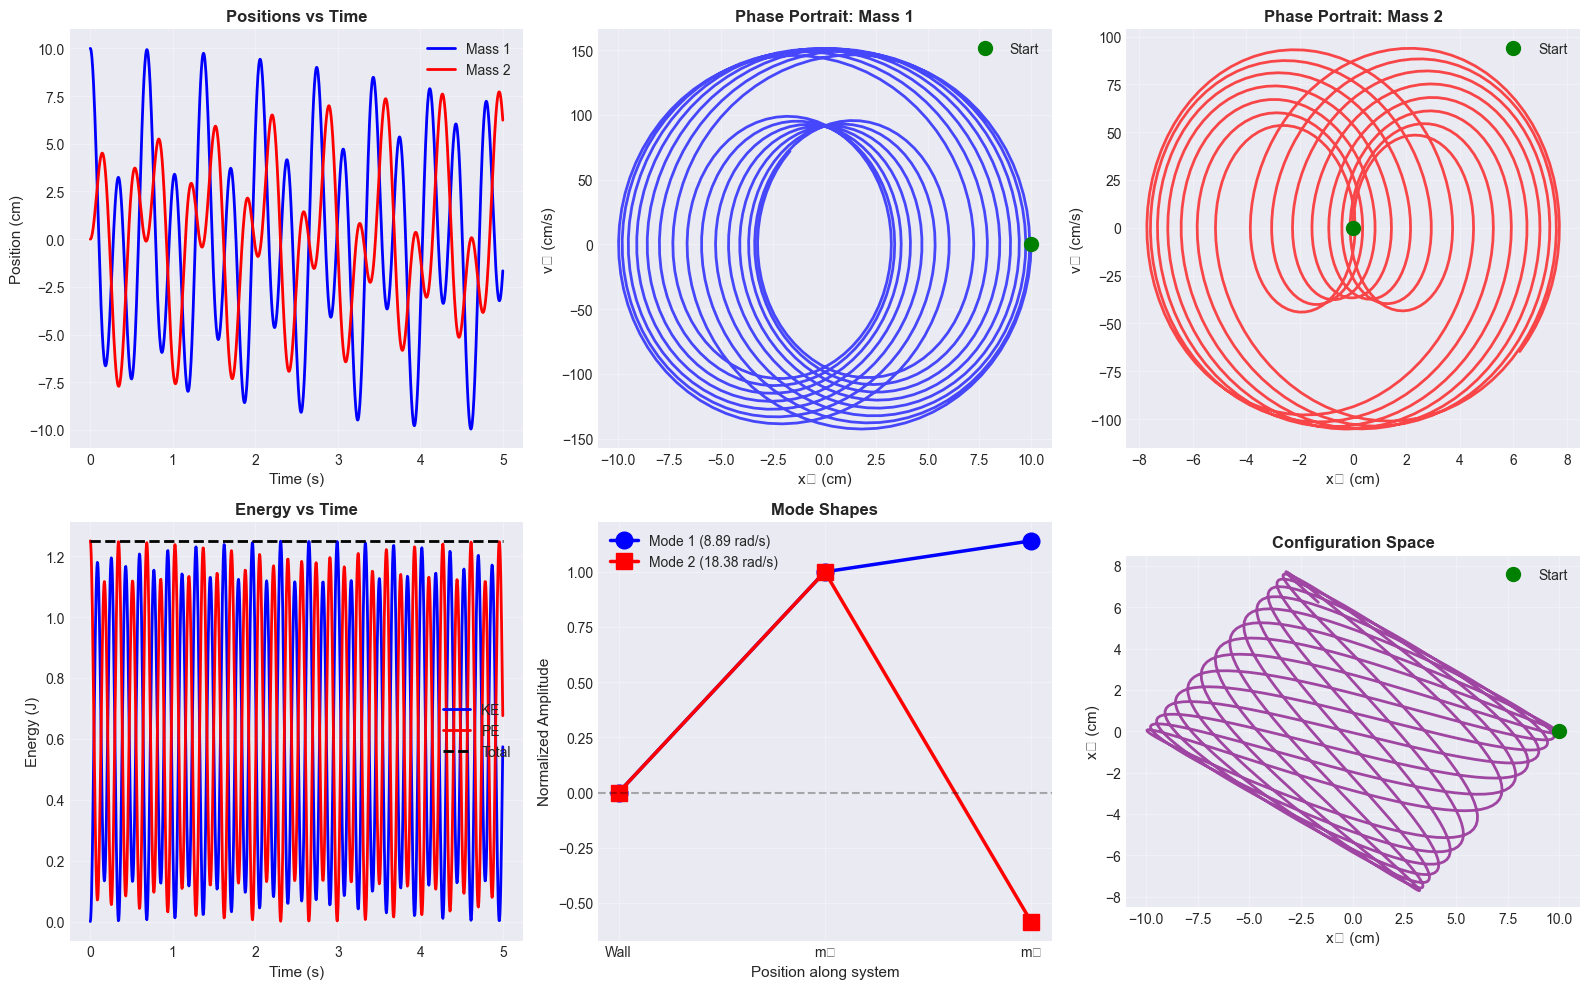


 Energy conservation: 1.250000 → 1.249999 J

 Key observations:
 1. Mode 1: Both masses oscillate together (lower frequency)
 2. Mode 2: Masses oscillate oppositely (higher frequency)
 3. Actual motion: Combination of both modes!


In [2]:
# Example 1: Two Masses with Three Springs

print("=" * 60)
print("Example 1: Coupled Mass-Spring System")
print("=" * 60)

# Given
m1 = 1.0  # kg
m2 = 1.5  # kg
k1 = 100.0  # N/m (left spring)
k2 = 150.0  # N/m (middle spring - coupling)
k3 = 100.0  # N/m (right spring)

# Mass and stiffness matrices
M = np.array([[m1, 0], [0, m2]])
K = np.array([[k1 + k2, -k2], [-k2, k2 + k3]])

print(f"\nSystem Properties:")
print(f"m₁ = {m1} kg, m₂ = {m2} kg")
print(f"k₁ = {k1} N/m, k₂ = {k2} N/m (coupling), k₃ = {k3} N/m")
print(f"\nMass Matrix M:")
print(M)
print(f"\nStiffness Matrix K:")
print(K)

# Solve eigenvalue problem: K·X = ω²·M·X
# Convert to standard form: M⁻¹·K·X = ω²·X
M_inv = np.linalg.inv(M)
A = M_inv @ K

eigenvalues, eigenvectors = np.linalg.eig(A)
omega_n = np.sqrt(eigenvalues)  # Natural frequencies
mode_shapes = eigenvectors  # Mode shapes

# Sort by frequency
idx = np.argsort(omega_n)
omega_n = omega_n[idx]
mode_shapes = mode_shapes[:, idx]

print(f"\n Natural Frequencies:")
print(f"ω₁ = {omega_n[0]:.3f} rad/s = {omega_n[0]/(2*np.pi):.3f} Hz (Mode 1)")
print(f"ω₂ = {omega_n[1]:.3f} rad/s = {omega_n[1]/(2*np.pi):.3f} Hz (Mode 2)")
print(f"Ratio ω₂/ω₁ = {omega_n[1]/omega_n[0]:.3f}")

print(f"\n Mode Shapes (normalized):")
# Normalize so first element is 1
mode1 = mode_shapes[:, 0] / mode_shapes[0, 0]
mode2 = mode_shapes[:, 1] / mode_shapes[0, 1]
print(f"Mode 1: [{mode1[0]:.3f}, {mode1[1]:.3f}] - Same direction")
print(f"Mode 2: [{mode2[0]:.3f}, {mode2[1]:.3f}] - Opposite directions")

# Simulate system with ODE


def system_ode(y, t):
    """State: y = [x1, v1, x2, v2]"""
    x1, v1, x2, v2 = y

    # Accelerations from equations of motion
    a1 = -(k1 + k2) * x1 / m1 + k2 * x2 / m1
    a2 = k2 * x1 / m2 - (k2 + k3) * x2 / m2

    return [v1, a1, v2, a2]


# Initial conditions: Displace m1, release from rest
x1_0 = 0.1  # m
x2_0 = 0.0  # m
y0 = [x1_0, 0, x2_0, 0]

# Time array
t = np.linspace(0, 5, 1000)

# Solve
solution = odeint(system_ode, y0, t)
x1 = solution[:, 0]
v1 = solution[:, 1]
x2 = solution[:, 2]
v2 = solution[:, 3]

# Energy
KE = 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2
PE = 0.5 * k1 * x1**2 + 0.5 * k2 * (x2 - x1)**2 + 0.5 * k3 * x2**2
E_total = KE + PE

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Positions
ax1 = axes[0, 0]
ax1.plot(t, x1*100, 'b-', linewidth=2, label='Mass 1')
ax1.plot(t, x2*100, 'r-', linewidth=2, label='Mass 2')
ax1.set_xlabel('Time (s)', fontsize=11)
ax1.set_ylabel('Position (cm)', fontsize=11)
ax1.set_title('Positions vs Time', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Phase portraits
ax2 = axes[0, 1]
ax2.plot(x1*100, v1*100, 'b-', linewidth=2, alpha=0.7)
ax2.plot(x1[0]*100, v1[0]*100, 'go', markersize=10, label='Start')
ax2.set_xlabel('x₁ (cm)', fontsize=11)
ax2.set_ylabel('v₁ (cm/s)', fontsize=11)
ax2.set_title('Phase Portrait: Mass 1', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax3 = axes[0, 2]
ax3.plot(x2*100, v2*100, 'r-', linewidth=2, alpha=0.7)
ax3.plot(x2[0]*100, v2[0]*100, 'go', markersize=10, label='Start')
ax3.set_xlabel('x₂ (cm)', fontsize=11)
ax3.set_ylabel('v₂ (cm/s)', fontsize=11)
ax3.set_title('Phase Portrait: Mass 2', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Energy
ax4 = axes[1, 0]
ax4.plot(t, KE, 'b-', linewidth=2, label='KE')
ax4.plot(t, PE, 'r-', linewidth=2, label='PE')
ax4.plot(t, E_total, 'k--', linewidth=2, label='Total')
ax4.set_xlabel('Time (s)', fontsize=11)
ax4.set_ylabel('Energy (J)', fontsize=11)
ax4.set_title('Energy vs Time', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# Mode shapes visualization
ax5 = axes[1, 1]
x_pos = np.array([0, 1, 2])  # Wall, m1, m2 positions
mode1_viz = np.array([0, mode1[0], mode1[1]])
mode2_viz = np.array([0, mode2[0], mode2[1]])
ax5.plot(x_pos, mode1_viz, 'bo-', linewidth=2.5, markersize=12,
         label=f'Mode 1 ({omega_n[0]:.2f} rad/s)')
ax5.plot(x_pos, mode2_viz, 'rs-', linewidth=2.5, markersize=12,
         label=f'Mode 2 ({omega_n[1]:.2f} rad/s)')
ax5.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax5.set_xlabel('Position along system', fontsize=11)
ax5.set_ylabel('Normalized Amplitude', fontsize=11)
ax5.set_title('Mode Shapes', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(['Wall', 'm₁', 'm₂'])
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Configuration space
ax6 = axes[1, 2]
ax6.plot(x1*100, x2*100, 'purple', linewidth=2, alpha=0.7)
ax6.plot(x1[0]*100, x2[0]*100, 'go', markersize=10, label='Start')
ax6.set_xlabel('x₁ (cm)', fontsize=11)
ax6.set_ylabel('x₂ (cm)', fontsize=11)
ax6.set_title('Configuration Space', fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\n Energy conservation: {E_total[0]:.6f} → {E_total[-1]:.6f} J")
print(f"\n Key observations:")
print(f"1. Mode 1: Both masses oscillate together (lower frequency)")
print(f"2. Mode 2: Masses oscillate oppositely (higher frequency)")
print(f"3. Actual motion: Combination of both modes!")

# TODO: Use these parameters in your solutions below


---
### What This Graph Tells You

**Positions (top-left):** The masses oscillate with a complex COMBINED motion. Energy transfers between them periodically — this is the **beating phenomenon**, where motion amplitude periodically swells and shrinks.

**Phase Portraits (top-middle, top-right):** Closed loops confirm periodic, energy-conserving behavior. The shape is NOT a simple ellipse because two frequencies are superimposed.

**Energy (bottom-left):** Total energy is perfectly constant. KE and PE swap continuously, confirming conservation.

**Mode Shapes (bottom-middle):** This is the KEY insight — two distinct vibration patterns:
- **Mode 1** (in-phase, lower freq): Both masses move in the same direction. The middle spring barely stretches.
- **Mode 2** (out-of-phase, higher freq): Masses move in opposite directions. The middle spring stretches maximally.

**Key Observations:**
- ANY motion of this system is a **superposition of these two normal modes** — fundamental theorem of modal analysis
- The beating frequency is the difference of natural frequencies
- Each mode oscillates independently at its own frequency

> **Student Takeaway:** Complex-looking vibrations are actually simple when viewed through the lens of normal modes. EVERY linear vibrating system can be decomposed into independent modes. This is the foundation of structural dynamics.


---
## Part B: Double Pendulum 

### Setup
**System**: Two pendulums connected end-to-end
- Mass 1 (m₁) at end of rod 1 (length L₁)
- Mass 2 (m₂) at end of rod 2 (length L₂), attached to m₁
- **2 DOF**: angles θ₁, θ₂ (measured from vertical)

### Why is this special?
- **Chaotic dynamics!** Small changes in initial conditions → vastly different trajectories
- **Nonlinear coupling**: Equations have sin/cos products
- **No general solution**: Must solve numerically

### Equations of Motion (Lagrangian)

**Positions** (Cartesian):
$$x_1 = L_1 \sin\theta_1, \quad y_1 = -L_1 \cos\theta_1$$
$$x_2 = L_1 \sin\theta_1 + L_2 \sin\theta_2, \quad y_2 = -L_1 \cos\theta_1 - L_2 \cos\theta_2$$

**Kinetic energy**:
$$T = \frac{1}{2}m_1(\dot{x}_1^2 + \dot{y}_1^2) + \frac{1}{2}m_2(\dot{x}_2^2 + \dot{y}_2^2)$$

After differentiation:
$$T = \frac{1}{2}(m_1 + m_2)L_1^2\dot{\theta}_1^2 + \frac{1}{2}m_2 L_2^2\dot{\theta}_2^2 + m_2 L_1 L_2 \dot{\theta}_1\dot{\theta}_2\cos(\theta_1 - \theta_2)$$

**Potential energy**:
$$V = m_1 g y_1 + m_2 g y_2 = -(m_1 + m_2)g L_1 \cos\theta_1 - m_2 g L_2 \cos\theta_2$$

**Lagrange equations**: $\frac{d}{dt}\frac{\partial L}{\partial \dot{\theta}_i} - \frac{\partial L}{\partial \theta_i} = 0$

**Result** (complex!):
$$(m_1 + m_2)L_1^2\ddot{\theta}_1 + m_2 L_1 L_2 \ddot{\theta}_2\cos(\theta_1-\theta_2) + m_2 L_1 L_2 \dot{\theta}_2^2\sin(\theta_1-\theta_2) + (m_1+m_2)g L_1\sin\theta_1 = 0$$

$$m_2 L_2^2\ddot{\theta}_2 + m_2 L_1 L_2 \ddot{\theta}_1\cos(\theta_1-\theta_2) - m_2 L_1 L_2 \dot{\theta}_1^2\sin(\theta_1-\theta_2) + m_2 g L_2\sin\theta_2 = 0$$

### Key Features

**Nonlinear terms**:
- $\dot{\theta}_1^2\sin(\theta_1-\theta_2)$ → centrifugal-like effect
- $\cos(\theta_1-\theta_2)$ → coupling depends on relative angle!

**Small angle approximation** ($\sin\theta \approx \theta$, $\cos\theta \approx 1$):
- System becomes linear (like two-mass-spring)
- Has normal modes, predictable oscillations
- **Large angles**: Nonlinearity → chaos!

**Sensitivity to initial conditions**:
- Two pendulums starting 0.001° apart → completely different after ~10s
- This is **deterministic chaos**: equations known, but long-term prediction impossible

---


![Double Pendulum Setup \u2014 Two Linked Pendulums Create Chaotic Motion](figs/U5_L3_double_pendulum.png)

<div align="center">
<img src="figs/U5_L3_double_pendulum_chaos.gif" alt="Double Pendulum Chaotic Motion \u2014 Unpredictable Yet Deterministic" width="600">
<p><em>Double Pendulum Chaotic Motion \u2014 Unpredictable Yet Deterministic</em></p>
</div>

Example 2: Double Pendulum Dynamics

Double Pendulum Properties:
 m₁ = 1.0 kg, L₁ = 1.0 m
 m₂ = 1.0 kg, L₂ = 1.0 m

⏳ Simulating (this may take a moment)...
 Simulation complete!


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_79776\2850507496.py:149: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 plt.tight_layout()
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_79776\2850507496.py:149: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 plt.tight_layout()


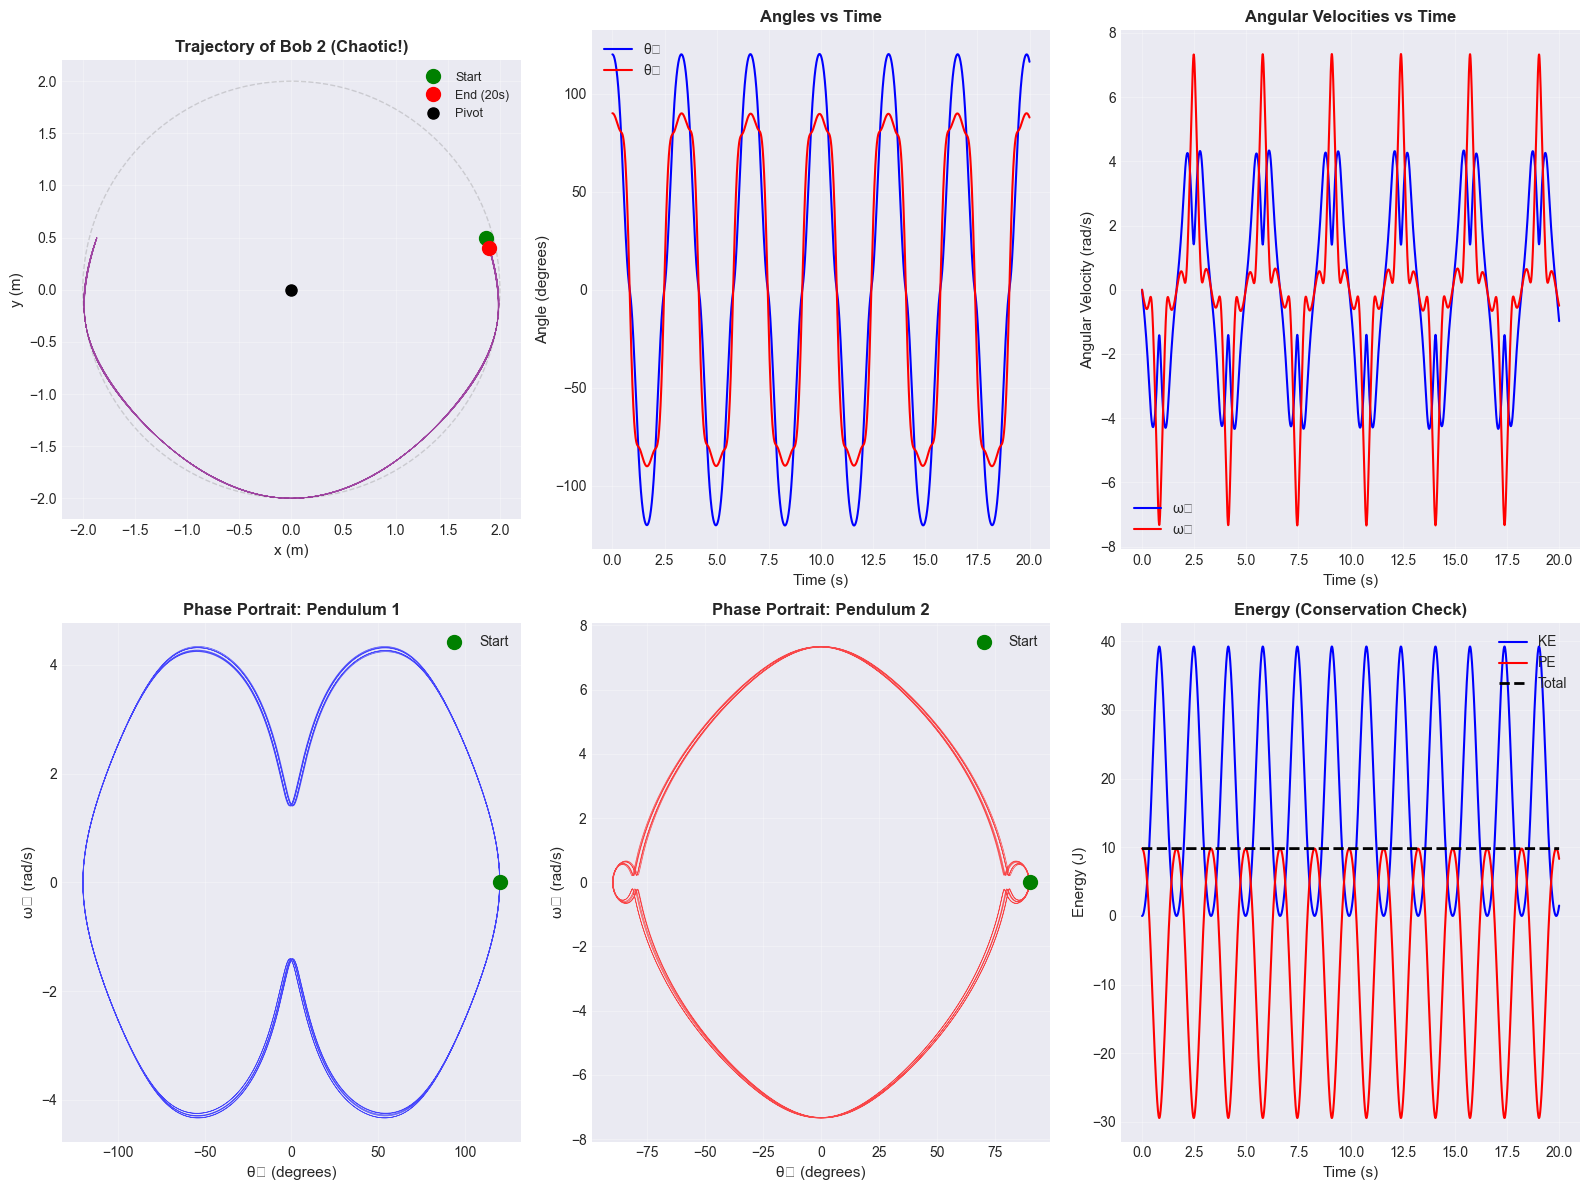


 Statistics:
 Energy conservation: 9.810000 → 9.809996 J
 Error: 0.0000%
 Max ω₁: 4.34 rad/s
 Max ω₂: 7.34 rad/s

 Chaos characteristics:
 1. Trajectory: Complex, never repeats exactly
 2. Phase portraits: Fill space (not simple loops)
 3. Energy exchanges wildly between pendulums
 4. Small IC change → completely different motion!


In [3]:
# Example 2: Double Pendulum - Chaotic Motion

print("=" * 60)
print("Example 2: Double Pendulum Dynamics")
print("=" * 60)

# Given
m1 = 1.0  # kg
m2 = 1.0  # kg
L1 = 1.0  # m
L2 = 1.0  # m
g = 9.81  # m/s^2

print(f"\nDouble Pendulum Properties:")
print(f"m₁ = {m1} kg, L₁ = {L1} m")
print(f"m₂ = {m2} kg, L₂ = {L2} m")


def double_pendulum_ode(y, t, m1, m2, L1, L2, g):
    """
    Double pendulum equations of motion
    State: y = [θ₁, ω₁, θ₂, ω₂]
    """
    theta1, omega1, theta2, omega2 = y

    # Precompute common terms
    delta = theta2 - theta1
    den1 = (m1 + m2) * L1 - m2 * L1 * np.cos(delta) * np.cos(delta)
    den2 = (L2 / L1) * den1

    # Angular accelerations (from solving coupled equations)
    alpha1 = (m2 * L1 * omega1**2 * np.sin(delta) * np.cos(delta)
              + m2 * g * np.sin(theta2) * np.cos(delta)
              + m2 * L2 * omega2**2 * np.sin(delta)
              - (m1 + m2) * g * np.sin(theta1)) / den1

    alpha2 = (-m2 * L2 * omega2**2 * np.sin(delta) * np.cos(delta)
              + (m1 + m2) * g * np.sin(theta1) * np.cos(delta)
              - (m1 + m2) * L1 * omega1**2 * np.sin(delta)
              - (m1 + m2) * g * np.sin(theta2)) / den2

    return [omega1, alpha1, omega2, alpha2]


# Initial conditions (degrees converted to radians)
theta1_0 = np.radians(120)  # Start at 120 degrees
theta2_0 = np.radians(90)  # 90 degrees
y0 = [theta1_0, 0, theta2_0, 0]  # Released from rest

# Time array
t = np.linspace(0, 20, 5000)  # 20 seconds, high resolution

# Solve
print("\n⏳ Simulating (this may take a moment)...")
solution = odeint(double_pendulum_ode, y0, t, args=(m1, m2, L1, L2, g))
theta1 = solution[:, 0]
omega1 = solution[:, 1]
theta2 = solution[:, 2]
omega2 = solution[:, 3]

# Cartesian positions for plotting
x1 = L1 * np.sin(theta1)
y1 = -L1 * np.cos(theta1)
x2 = x1 + L2 * np.sin(theta2)
y2 = y1 - L2 * np.cos(theta2)

# Energy
v1_x = L1 * omega1 * np.cos(theta1)
v1_y = L1 * omega1 * np.sin(theta1)
v2_x = v1_x + L2 * omega2 * np.cos(theta2)
v2_y = v1_y + L2 * omega2 * np.sin(theta2)

KE = 0.5 * m1 * (v1_x**2 + v1_y**2) + 0.5 * m2 * (v2_x**2 + v2_y**2)
PE = m1 * g * y1 + m2 * g * y2
E_total = KE + PE

print("Simulation complete!")

# Plotting
fig = plt.figure(figsize=(16, 12))

# Trajectory of bob 2
ax1 = plt.subplot(2, 3, 1)
ax1.plot(x2, y2, 'purple', linewidth=0.5, alpha=0.7)
ax1.plot(x2[0], y2[0], 'go', markersize=10, label='Start')
ax1.plot(x2[-1], y2[-1], 'ro', markersize=10, label='End (20s)')
ax1.plot(0, 0, 'ko', markersize=8, label='Pivot')
# Draw circle showing maximum reach
circle = plt.Circle((0, 0), L1 + L2, fill=False,
                    color='gray', linestyle='--', alpha=0.3)
ax1.add_patch(circle)
ax1.set_xlim([-(L1+L2)*1.1, (L1+L2)*1.1])
ax1.set_ylim([-(L1+L2)*1.1, (L1+L2)*1.1])
ax1.set_aspect('equal')
ax1.set_xlabel('x (m)', fontsize=11)
ax1.set_ylabel('y (m)', fontsize=11)
ax1.set_title('Trajectory of Bob 2 (Chaotic!)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Angles vs time
ax2 = plt.subplot(2, 3, 2)
ax2.plot(t, np.degrees(theta1), 'b-', linewidth=1.5, label='θ₁')
ax2.plot(t, np.degrees(theta2), 'r-', linewidth=1.5, label='θ₂')
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Angle (degrees)', fontsize=11)
ax2.set_title('Angles vs Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Angular velocities
ax3 = plt.subplot(2, 3, 3)
ax3.plot(t, omega1, 'b-', linewidth=1.5, label='ω₁')
ax3.plot(t, omega2, 'r-', linewidth=1.5, label='ω₂')
ax3.set_xlabel('Time (s)', fontsize=11)
ax3.set_ylabel('Angular Velocity (rad/s)', fontsize=11)
ax3.set_title('Angular Velocities vs Time', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Phase portrait: θ₁ vs ω₁
ax4 = plt.subplot(2, 3, 4)
ax4.plot(np.degrees(theta1), omega1, 'b-', linewidth=0.5, alpha=0.7)
ax4.plot(np.degrees(theta1[0]), omega1[0], 'go', markersize=10, label='Start')
ax4.set_xlabel('θ₁ (degrees)', fontsize=11)
ax4.set_ylabel('ω₁ (rad/s)', fontsize=11)
ax4.set_title('Phase Portrait: Pendulum 1', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# Phase portrait: θ₂ vs ω₂
ax5 = plt.subplot(2, 3, 5)
ax5.plot(np.degrees(theta2), omega2, 'r-', linewidth=0.5, alpha=0.7)
ax5.plot(np.degrees(theta2[0]), omega2[0], 'go', markersize=10, label='Start')
ax5.set_xlabel('θ₂ (degrees)', fontsize=11)
ax5.set_ylabel('ω₂ (rad/s)', fontsize=11)
ax5.set_title('Phase Portrait: Pendulum 2', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Energy
ax6 = plt.subplot(2, 3, 6)
ax6.plot(t, KE, 'b-', linewidth=1.5, label='KE')
ax6.plot(t, PE, 'r-', linewidth=1.5, label='PE')
ax6.plot(t, E_total, 'k--', linewidth=2, label='Total')
ax6.set_xlabel('Time (s)', fontsize=11)
ax6.set_ylabel('Energy (J)', fontsize=11)
ax6.set_title('Energy (Conservation Check)', fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Statistics:")
print(f"Energy conservation: {E_total[0]:.6f} → {E_total[-1]:.6f} J")
print(f"Error: {abs(E_total[-1] - E_total[0])/E_total[0]*100:.4f}%")
print(f"Max ω₁: {np.max(np.abs(omega1)):.2f} rad/s")
print(f"Max ω₂: {np.max(np.abs(omega2)):.2f} rad/s")

print(f"\n Chaos characteristics:")
print(f"1. Trajectory: Complex, never repeats exactly")
print(f"2. Phase portraits: Fill space (not simple loops)")
print(f"3. Energy exchanges wildly between pendulums")
print(f"4. Small IC change → completely different motion!")

# TODO: Use these parameters in your solutions below


---
### What This Graph Tells You

**Trajectory (top-left):** The path of the second bob NEVER repeats — this is the hallmark of **deterministic chaos**. Despite being governed by precise equations, the motion appears random.

**Angles vs. Time (top-middle, top-right):** Both $\theta_1(t)$ and $\theta_2(t)$ show irregular oscillations with no discernible period. Compare this to the regular sinusoidal motion of a simple pendulum.

**Phase Portraits (bottom-left, bottom-middle):** Instead of closed loops (periodic) or spirals (damped), the trajectories **fill a region of phase space**. This is the signature of a chaotic attractor.

**Energy (bottom-right):** Total energy is CONSTANT (confirming correctness of our simulation), but energy **oscillates unpredictably** between the two pendulums.

**Key Observations:**
- Chaos requires: (1) nonlinear coupling, (2) at least 3 state variables, (3) sensitivity to initial conditions
- The double pendulum has 4 state variables ($\theta_1, \theta_2, \omega_1, \omega_2$) and strong nonlinear coupling ($\sin(\theta_1 - \theta_2)$ terms)
- This is fundamentally different from the linear 2-mass spring system (which was periodic, not chaotic)
- The equations are perfectly deterministic — chaos $\neq$ randomness!

> **Student Takeaway:** Not all dynamical systems are predictable. When nonlinearity is strong enough, even simple systems (just 2 pendulums!) become chaotic. This has profound implications for weather prediction, turbulence, and any nonlinear engineering system.

In [ ]:
# TODO: Create visualization# Hint: Use matplotlib to plot your results## Suggested structure:# 1. Create figure and axes# 2. Plot calculated results# 3. Add labels and formatting# 4. Display the plot# Your code here:

---
### What This Graph Tells You

**Comparison (top panels):** Two simulations started with only **0.01\u00b0 difference** in $\theta_1$ produce IDENTICAL trajectories for the first ~2 seconds, then **completely diverge**.

**Divergence (bottom-left, semilog):** The angular difference grows **exponentially** — a straight line on the log scale. This is the defining characteristic of chaos.

**Key Numbers:**
- Lyapunov exponent $\lambda \approx 0.15$/s means the error **doubles every ~4.6 seconds**
- After 10 seconds: a 0.01\u00b0 error grows to ~30\u00b0 (completely different motion)
- After 20 seconds: the two systems have NO correlation whatsoever

**Why This Matters for Engineering:**
- Weather prediction has a fundamental limit (~10–14 days) because of this exponential divergence
- Turbulent fluid flow is chaotic — exact long-term prediction is impossible
- Chaotic systems CANNOT be predicted by more precise measurements alone (precision helps, but only buys a few more seconds)
- BUT: short-term prediction IS possible and useful (chaos $\neq$ uselessness)

> **Student Takeaway:** The butterfly effect is real and quantifiable. The Lyapunov exponent tells you exactly how fast predictions degrade. For engineering design, this means some systems require FEEDBACK CONTROL rather than open-loop prediction.

---
## Summary

### Key Concepts

**1. Multi-DOF Systems**
- **Degrees of Freedom**: Number of independent coordinates
- **Coupled equations**: Motion of one DOF affects others
- **Matrix form**: $\mathbf{M}\ddot{\mathbf{q}} + \mathbf{C}\dot{\mathbf{q}} + \mathbf{K}\mathbf{q} = \mathbf{F}$

**2. Two-Mass-Spring System**
- Linear coupling through springs
- **Normal modes**: Special patterns where both masses oscillate at same frequency
- **Eigenvalue problem**: $\det(\mathbf{K} - \omega^2\mathbf{M}) = 0$
- Natural frequencies: $\omega_1, \omega_2$
- Mode shapes: How masses move relative to each other

**3. Double Pendulum**
- **Nonlinear coupling**: Equations have $\sin(\theta_1 - \theta_2)$ terms
- **Chaotic dynamics**: Sensitive to initial conditions
- **Butterfly effect**: 0.01° difference → completely different after ~10s
- **Energy exchange**: Irregular transfer between pendulums

### Problem-Solving Strategy

**For coupled systems**:
1. **Identify DOF**: Count independent coordinates
2. **Choose coordinates**: Generalized coordinates (angles, positions)
3. **Derive equations**:
 - **Newton-Euler**: FBD for each body, write ΣF = ma and Στ = Iα
 - **Lagrange**: $L = T - V$, then $\frac{d}{dt}\frac{\partial L}{\partial \dot{q}_i} - \frac{\partial L}{\partial q_i} = 0$
4. **Write matrix form**: Identify $\mathbf{M}$, $\mathbf{K}$, $\mathbf{C}$ matrices
5. **Solve**:
 - **Linear**: Eigenvalue problem for modes
 - **Nonlinear**: Numerical integration (odeint)

### Physical Insights

**Normal modes** (linear systems):
- System oscillates with single frequency
- All parts move in fixed ratio (mode shape)
- General motion = superposition of modes

**Chaos** (nonlinear systems):
- Long-term unpredictability despite deterministic equations
- Sensitive dependence on initial conditions
- Common in nature: weather, turbulence, solar system

### Design Implications

- **Vibration control**: Design to avoid resonances (match frequencies)
- **Robots**: Account for coupling when controlling multiple joints
- **Structures**: Multiple modes can be excited by earthquakes
- **Chaos**: Can be useful (mixing) or problematic (prediction)

### Connection to Vibrations (Unit 5.2)

This lecture sets the stage:
- **SDOF vibrations**: One mass-spring (next lecture)
- **MDOF vibrations**: Multiple masses (modal analysis)
- **Damping**: Add $\mathbf{C}\dot{\mathbf{q}}$ terms
- **Forced response**: Add $\mathbf{F}(t)$ forcing

### What's Next?

**Unit 5 Lecture 4**: Introduction to Vibrations
- Single DOF vibrations (SDOF)
- Natural frequency $\omega_n = \sqrt{k/m}$
- Damping ratio $\zeta$
- Free and forced response
- Resonance

---

### Practice Problems

1. **Three masses**: Add third mass to spring system, find 3 natural frequencies
2. **Double pendulum**: Small angles → linearize equations, find normal modes
3. **Triple pendulum**: Even more chaotic! Try simulating
4. **Robot arm**: Two links with motors, derive equations with torque inputs

---
